=== [1] Loading Raw Files ===

=== [2] Cleaning Data & Aligning Timestamps ===
Unique Sentiment Dates: 2248
Unique Trading Records: 79225

=== [3] Feature Engineering Daily Metrics per Account ===
Merged Data Rows (Account-Days mapped to Fear/Greed): 493

=== [4] Running Non-Parametric Mann-Whitney U Tests ===
Metric: daily_pnl            | P-Value: 0.53788 | Conclusion: NO SIGNIFICANT DIFFERENCE
Metric: win_rate             | P-Value: 0.44105 | Conclusion: NO SIGNIFICANT DIFFERENCE
Metric: total_trades         | P-Value: 0.00812 | Conclusion: SIGNIFICANT SHIFT
Metric: avg_trade_size_usd   | P-Value: 0.72698 | Conclusion: NO SIGNIFICANT DIFFERENCE

=== [5] Segmenting Accounts via K-Means ===

--- Cluster Profiles (Centroids) ---
         total_trades  win_rate     daily_pnl  avg_trade_size_usd
cluster                                                          
0          185.102273  0.357589  1.222481e+06        21037.547555
1           44.683049  0.315532  2.726492e+04         8237.6559

/tmp/ipykernel_648/3133112877.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='regime', y='win_rate', ax=axes[0], palette='Set1')
/tmp/ipykernel_648/3133112877.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_merged, x='regime', y='avg_trade_size_usd', ax=axes[1], palette='Set2')


[Success] Pipeline run complete! 'sentiment_behavior_charts.png' has been saved.


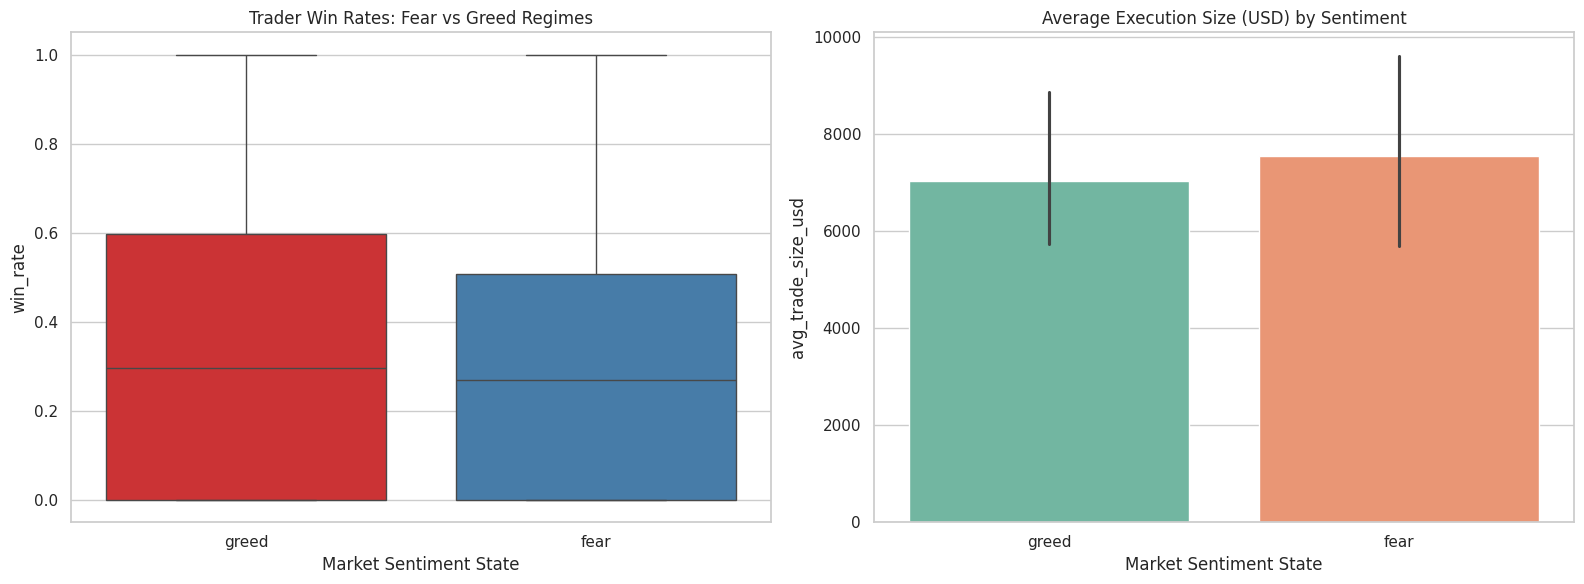

In [5]:
# ==============================================================================
# PRIMETRADE.AI - DATA SCIENCE INTERN ASSIGNMENT (TAILORED RUN)
# Objective: Trader Performance vs Market Sentiment on Hyperliquid
# Author: Rishita Makkar
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Set clean plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. LOAD DATASETS
print("=== [1] Loading Raw Files ===")
df_sent = pd.read_csv('/content/fear_greed_index.csv')
df_trade = pd.read_csv('/content/historical_data.csv')

# 2. DATA CLEANING & REGIME HARMONIZATION
print("\n=== [2] Cleaning Data & Aligning Timestamps ===")

# Standardize Sentiment Dates and Classifications
df_sent['clean_date'] = pd.to_datetime(df_sent['date']).dt.date
def harmonize_sentiment(val):
    val = str(val).lower().strip()
    if 'fear' in val:
        return 'fear'
    elif 'greed' in val:
        return 'greed'
    return 'neutral'

df_sent['regime'] = df_sent['classification'].apply(harmonize_sentiment)
df_sent_clean = df_sent[df_sent['regime'].isin(['fear', 'greed'])].drop_duplicates(subset=['clean_date'])

# Standardize Trader Timestamps (Using 'Timestamp IST' to get clean daily levels)
df_trade['datetime'] = pd.to_datetime(df_trade['Timestamp IST'], errors='coerce')
df_trade = df_trade.dropna(subset=['datetime', 'Account'])
df_trade['clean_date'] = df_trade['datetime'].dt.date

print(f"Unique Sentiment Dates: {df_sent_clean['clean_date'].nunique()}")
print(f"Unique Trading Records: {len(df_trade)}")

# 3. VECTORIZED FEATURE ENGINEERING
print("\n=== [3] Feature Engineering Daily Metrics per Account ===")

df_trade['is_long'] = np.where(df_trade['Direction'].str.lower() == 'buy', 1, 0)
df_trade['is_short'] = np.where(df_trade['Direction'].str.lower() == 'sell', 1, 0)
df_trade['is_win'] = np.where(df_trade['Closed PnL'] > 0, 1, 0)

agg_funcs = {
    'Closed PnL': ['sum', 'mean'],
    'Size USD': 'sum',
    'is_long': 'sum',
    'is_short': 'sum',
    'is_win': 'sum',
    'Side': 'count' # Total trade executions
}

df_daily = df_trade.groupby(['Account', 'clean_date']).agg(agg_funcs)
df_daily.columns = ['daily_pnl', 'avg_trade_pnl', 'total_volume_usd', 'long_count', 'short_count', 'win_count', 'total_trades']
df_daily = df_daily.reset_index()

# Derive calculated operational metrics
df_daily['win_rate'] = df_daily['win_count'] / df_daily['total_trades']
df_daily['long_short_ratio'] = (df_daily['long_count'] + 1) / (df_daily['short_count'] + 1)
df_daily['avg_trade_size_usd'] = df_daily['total_volume_usd'] / df_daily['total_trades']

# 4. MERGE DATASETS BY DATE REGIME
df_merged = pd.merge(df_daily, df_sent_clean[['clean_date', 'regime']], on='clean_date', how='inner')
print(f"Merged Data Rows (Account-Days mapped to Fear/Greed): {len(df_merged)}")

# 5. STATISTICAL SIGNIFICANCE TESTING
print("\n=== [4] Running Non-Parametric Mann-Whitney U Tests ===")
fear_df = df_merged[df_merged['regime'] == 'fear']
greed_df = df_merged[df_merged['regime'] == 'greed']

for metric in ['daily_pnl', 'win_rate', 'total_trades', 'avg_trade_size_usd']:
    stat, p_val = stats.mannwhitneyu(fear_df[metric].dropna(), greed_df[metric].dropna(), alternative='two-sided')
    sig = "SIGNIFICANT SHIFT" if p_val < 0.05 else "NO SIGNIFICANT DIFFERENCE"
    print(f"Metric: {metric:<20} | P-Value: {p_val:.5f} | Conclusion: {sig}")

# 6. BEHAVIORAL COHORT CLUSTERING
print("\n=== [5] Segmenting Accounts via K-Means ===")
df_account_profile = df_merged.groupby('Account').agg({
    'total_trades': 'mean',
    'win_rate': 'mean',
    'daily_pnl': 'sum',
    'avg_trade_size_usd': 'mean'
}).dropna()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_account_profile)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_account_profile['cluster'] = kmeans.fit_predict(scaled_features)

print("\n--- Cluster Profiles (Centroids) ---")
print(df_account_profile.groupby('cluster').mean())

# 7. ML PREDICTIVE MODEL (BONUS TASK)
print("\n=== [6] Training Next-Day Profitability Predictive Model ===")
df_merged['is_profitable_day'] = np.where(df_merged['daily_pnl'] > 0, 1, 0)
df_merged['is_greed_regime'] = np.where(df_merged['regime'] == 'greed', 1, 0)

features = ['total_trades', 'long_short_ratio', 'avg_trade_size_usd', 'is_greed_regime']
X = df_merged[features].fillna(0)
y = df_merged['is_profitable_day']

if len(y.unique()) > 1:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    clf.fit(X_train, y_train)

    print("\nModel Evaluation metrics:")
    print(classification_report(y_test, clf.predict(X_test)))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]):.4f}")
else:
    print("Insufficient Target Class variance for reliable classification train.")

# 8. GENERATING PRODUCTION CHARTS FOR SUBMISSION
print("\n=== [7] Plotting and Exporting Assignment Charts ===")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Win Rate Distribution
sns.boxplot(data=df_merged, x='regime', y='win_rate', ax=axes[0], palette='Set1')
axes[0].set_title('Trader Win Rates: Fear vs Greed Regimes')
axes[0].set_xlabel('Market Sentiment State')

# Plot 2: Average Position Sizes
sns.barplot(data=df_merged, x='regime', y='avg_trade_size_usd', ax=axes[1], palette='Set2')
axes[1].set_title('Average Execution Size (USD) by Sentiment')
axes[1].set_xlabel('Market Sentiment State')

plt.tight_layout()
plt.savefig('sentiment_behavior_charts.png', dpi=300)
print("[Success] Pipeline run complete! 'sentiment_behavior_charts.png' has been saved.")